## The Mackerel Revolution

For most of the twentieth century, mackerel was almost absent from Icelandic fisheries. However, during the late 2000s, warming ocean temperatures caused mackerel stocks to migrate further north into Icelandic waters. Within roughly a decade, mackerel went from barely being fished in Iceland to becoming one of the country’s most valuable species.

The data shows a dramatic rise in both mackerel catch and value after around 2007. By the 2010s, mackerel had become equally or even more valuable than haddock, which had been one of the foundations of Icelandic fisheries for decades. The rise of mackerel helped offset losses from declining capelin catches and significantly changed the structure of Iceland’s fishing industry.

### References

- Hafrannsóknastofnun (Marine and Freshwater Research Institute, Iceland):  https://www.hafogvatn.is/is/veidiradgjof/makrill 

- https://is.wikipedia.org/wiki/Makr%C3%ADll 

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os 

In [10]:
combined_df = pd.read_csv('combined_fish_data.csv')
df_yearly = pd.read_csv('yearly_fish_data.csv')

In [11]:
# --- Theme colors  ---
BG = "#0d1117"
PANEL = "#161b22"
GRID = "#30363d"
TEXT = "#c9d1d9"
MUTED = "#8b949e"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": TEXT,
    "axes.titlecolor": "#f0f6fc",
    "grid.color": GRID,
    "legend.facecolor": PANEL,
    "legend.edgecolor": GRID,
    "font.family": "DejaVu Sans"
})

# --- Original-style distinct matplotlib colors ---
SPECIES_COLORS = {
    "Capelin": "#1f77b4",        # blue
    "Cod": "#ff7f0e",   # orange
    "Haddock": "#2ca02c",   # green
    "Herring": "#d62728",   # red
    "Mackerel": "#9467bd",  # purple
}

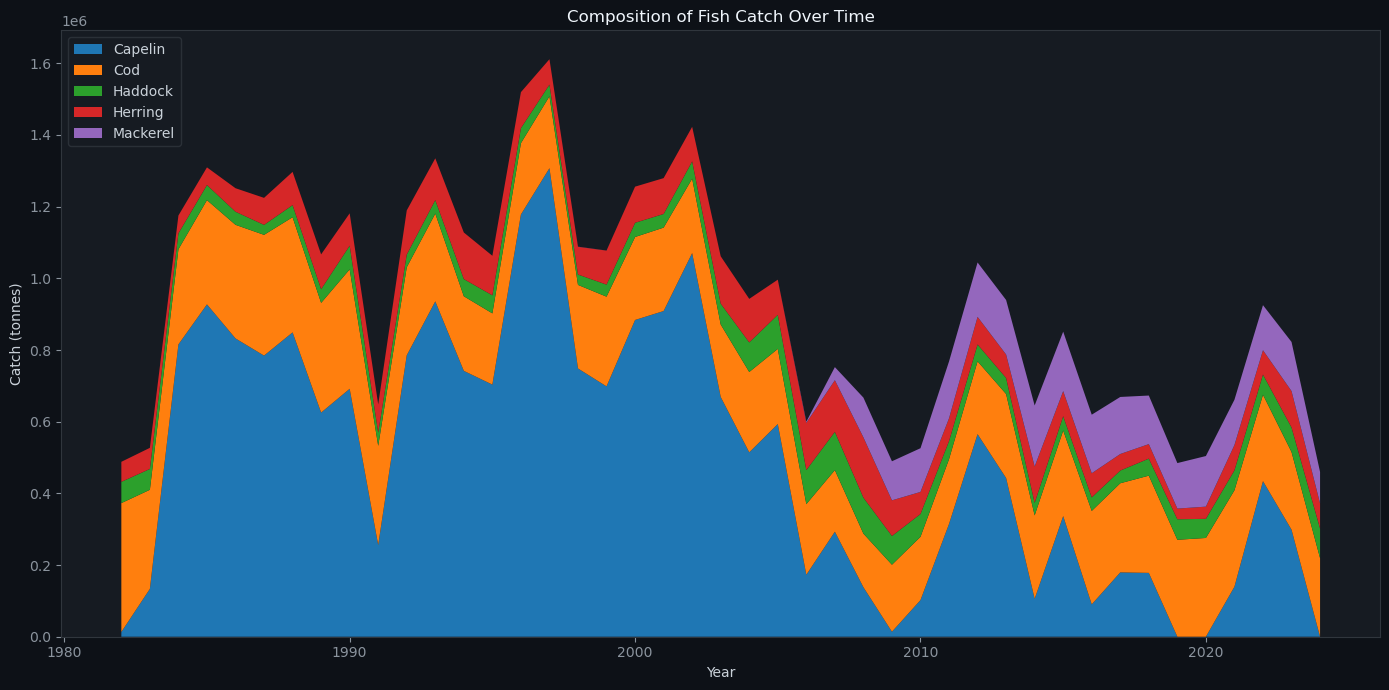

In [12]:
species_yearly = (
    df_yearly
    .groupby(["Year", "Species"], as_index=False)["Quantity"]
    .sum()
)

pivot_species = species_yearly.pivot(
    index="Year",
    columns="Species",
    values="Quantity"
)

plt.figure(figsize=(14, 7))

plt.stackplot(
    pivot_species.index,
    pivot_species.T,
    labels=pivot_species.columns
)

plt.title("Composition of Fish Catch Over Time")
plt.xlabel("Year")
plt.ylabel("Catch (tonnes)")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

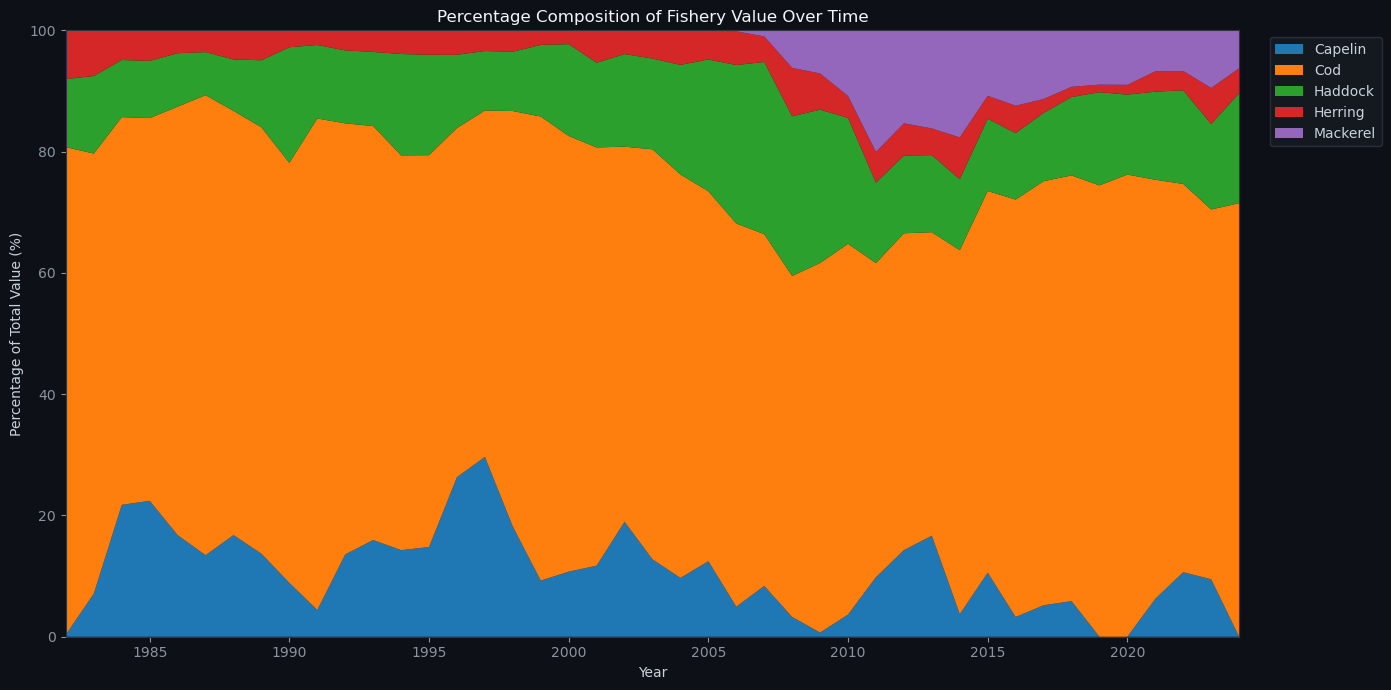

In [13]:
# Value by species and year
species_value_yearly = (
    df_yearly
    .groupby(["Year", "Species"], as_index=False)["Value"]
    .sum()
)

pivot_value = species_value_yearly.pivot(
    index="Year",
    columns="Species",
    values="Value"
).fillna(0)

# Calculate percentage: divide each row's values by the row's sum, multiply by 100
pivot_pct = pivot_value.div(pivot_value.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))

# Plot using the percentage data
plt.stackplot(
    pivot_pct.index,
    pivot_pct.T,
    labels=pivot_pct.columns
)

plt.title("Percentage Composition of Fishery Value Over Time")
plt.xlabel("Year")
plt.ylabel("Percentage of Total Value (%)")

# Cap the y-axis at 100% for a clean look
plt.ylim(0, 100)
plt.margins(x=0) # Removes empty white space on the left and right

# Move the legend outside the plot area so it doesn't overlap the filled area
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [14]:
import base64, io

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=150,
                facecolor=fig.get_facecolor())
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

# ── Theme ──────────────────────────────────────────────────────────────────────
BG    = "#0d1117"
PANEL = "#161b22"
GRID  = "#30363d"
TEXT  = "#c9d1d9"
MUTED = "#8b949e"

plt.rcParams.update({
    "figure.facecolor": BG,   "axes.facecolor": PANEL,
    "axes.edgecolor":   GRID, "axes.labelcolor": TEXT,
    "xtick.color": MUTED,     "ytick.color": MUTED,
    "text.color":  TEXT,      "axes.titlecolor": "#f0f6fc",
    "grid.color":  GRID,      "legend.facecolor": PANEL,
    "legend.edgecolor": GRID, "font.family": "DejaVu Sans",
})

SPECIES_COLORS = {
    "Capelin":  "#1f77b4",
    "Cod":      "#ff7f0e",
    "Haddock":  "#2ca02c",
    "Herring":  "#d62728",
    "Mackerel": "#9467bd",
}

# ── Plot 1 — catch composition by quantity ────────────────────────────────────
species_yearly = (
    df_yearly.groupby(["Year", "Species"], as_index=False)["Quantity"].sum()
)
pivot_species = species_yearly.pivot(index="Year", columns="Species", values="Quantity")
colors1 = [SPECIES_COLORS.get(c, "#aaaaaa") for c in pivot_species.columns]

fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.stackplot(pivot_species.index, pivot_species.T, labels=pivot_species.columns,
              colors=colors1, alpha=0.85)
ax1.set_title("Composition of Fish Catch Over Time")
ax1.set_xlabel("Year")
ax1.set_ylabel("Catch (tonnes)")
ax1.legend(loc="upper left")
ax1.margins(x=0)
plt.tight_layout()
img1 = fig_to_b64(fig1)
plt.close(fig1)

# ── Plot 2 — value composition as percentage ──────────────────────────────────
species_value_yearly = (
    df_yearly.groupby(["Year", "Species"], as_index=False)["Value"].sum()
)
pivot_value = species_value_yearly.pivot(
    index="Year", columns="Species", values="Value"
).fillna(0)
pivot_pct = pivot_value.div(pivot_value.sum(axis=1), axis=0) * 100
colors2 = [SPECIES_COLORS.get(c, "#aaaaaa") for c in pivot_pct.columns]

fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.stackplot(pivot_pct.index, pivot_pct.T, labels=pivot_pct.columns,
              colors=colors2, alpha=0.85)
ax2.set_title("Percentage Composition of Fishery Value Over Time")
ax2.set_xlabel("Year")
ax2.set_ylabel("Percentage of Total Value (%)")
ax2.set_ylim(0, 100)
ax2.margins(x=0)
ax2.legend(loc="upper left")
plt.tight_layout()
img2 = fig_to_b64(fig2)
plt.close(fig2)

# ── Text ───────────────────────────────────────────────────────────────────────
para1 = (
    "For most of the twentieth century, mackerel was almost absent from Icelandic "
    "fisheries. However, during the late 2000s, warming ocean temperatures caused "
    "mackerel stocks to migrate further north into Icelandic waters. Within roughly "
    "a decade, mackerel went from barely being fished in Iceland to becoming one of "
    "the country's most valuable species."
)
para2 = (
    "The data shows a dramatic rise in both mackerel catch and value after around 2007. "
    "By the 2010s, mackerel had become equally or even more valuable than haddock, which "
    "had been one of the foundations of Icelandic fisheries for decades. The rise of "
    "mackerel helped offset losses from declining capelin catches and significantly "
    "changed the structure of Iceland's fishing industry."
)

SHARED_CSS = """
  * { margin: 0; padding: 0; box-sizing: border-box; }
  body { font-family: 'DM Sans', sans-serif; background: #0d1117; color: #c9d1d9; }
  .navbar {
    position: fixed; top: 0; left: 0; right: 0; height: 52px;
    background: rgba(13,17,23,0.94); backdrop-filter: blur(12px);
    -webkit-backdrop-filter: blur(12px); border-bottom: 1px solid #21262d;
    z-index: 1000; display: flex; align-items: center; padding: 0 20px; gap: 14px;
  }
  .navbar-brand {
    font-size: 14px; font-weight: 700; color: #f0f6fc;
    white-space: nowrap; flex-shrink: 0; line-height: 1.15; text-decoration: none;
  }
  .navbar-brand .brand-sub {
    display: block; font-size: 10px; font-weight: 400; color: #8b949e; letter-spacing: 0.02em;
  }
  .navbar-sep { width: 1px; height: 26px; background: #21262d; flex-shrink: 0; }
  .stories-label {
    font-size: 10px; font-weight: 600; color: #484f58; text-transform: uppercase;
    letter-spacing: 0.08em; white-space: nowrap; flex-shrink: 0;
  }
  .story-tag { font-size: 12.5px; color: #c9d1d9; font-weight: 500; white-space: nowrap; flex-shrink: 0; }
  .navbar-spacer { flex: 1; }
  .back-link {
    display: flex; align-items: center; gap: 6px; font-size: 12.5px; color: #58a6ff;
    text-decoration: none; padding: 5px 11px; border-radius: 6px;
    border: 1px solid rgba(88,166,255,0.25); white-space: nowrap; flex-shrink: 0;
    transition: background 0.2s, border-color 0.2s;
  }
  .back-link:hover { background: rgba(88,166,255,0.1); border-color: rgba(88,166,255,0.5); }
  .story-wrap { max-width: 880px; margin: 0 auto; padding: 80px 32px 96px; }
  .story-meta {
    font-size: 11px; font-weight: 600; color: #484f58; text-transform: uppercase;
    letter-spacing: 0.1em; margin-bottom: 14px;
  }
  h1 {
    font-size: 34px; font-weight: 700; color: #f0f6fc; line-height: 1.25;
    letter-spacing: -0.5px; margin-bottom: 28px; padding-bottom: 24px;
    border-bottom: 1px solid #21262d;
  }
  .story-body p { font-size: 16px; line-height: 1.85; color: #c9d1d9; margin-bottom: 36px; }
  .story-figure { margin: 0 0 44px; }
  .story-figure img {
    width: 100%; border-radius: 8px; border: 1px solid #21262d;
    display: block; background: #161b22;
  }
  .story-figure figcaption {
    font-size: 12px; color: #484f58; margin-top: 8px;
    padding-left: 2px; font-style: italic; line-height: 1.5;
  }
  .references { border-top: 1px solid #21262d; padding-top: 28px; margin-top: 8px; }
  .references h2 {
    font-size: 13px; font-weight: 600; color: #484f58; text-transform: uppercase;
    letter-spacing: 0.08em; margin-bottom: 12px;
  }
  .references ul { list-style: none; display: flex; flex-direction: column; gap: 6px; }
  .references a { font-size: 13px; color: #58a6ff; text-decoration: none; }
  .references a:hover { text-decoration: underline; }
"""

# ── HTML ───────────────────────────────────────────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>The Mackerel Revolution — Iceland Fisheries</title>
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=DM+Sans:ital,wght@0,400;0,500;0,700;1,400&display=swap">
<style>{SHARED_CSS}</style>
</head>
<body>

<nav class="navbar">
  <a href="iceland_catch_map_slider.html" class="navbar-brand">
    Iceland Fisheries
    <span class="brand-sub">Interactive Map</span>
  </a>
  <div class="navbar-sep"></div>
  <span class="stories-label">Stories</span>
  <span class="story-tag">The Mackerel Revolution</span>
  <div class="navbar-spacer"></div>
  <a href="iceland_catch_map_slider.html" class="back-link">&#8592; Back to Map</a>
</nav>

<main class="story-wrap">
  <div class="story-meta">Species Analysis &middot; 1982–2024</div>
  <h1>The Mackerel Revolution</h1>

  <div class="story-body">

    <p>{para1}</p>

    <figure class="story-figure">
      <img src="data:image/png;base64,{img1}" alt="Composition of Fish Catch Over Time">
      <figcaption>Total catch by species stacked over time, 1982–2024. Mackerel's rapid emergence from near-zero is visible from around 2007 onward.</figcaption>
    </figure>

    <p>{para2}</p>

    <figure class="story-figure">
      <img src="data:image/png;base64,{img2}" alt="Percentage Composition of Fishery Value Over Time">
      <figcaption>Each species' share of total fishery value by year. Mackerel's growing economic weight becomes clear as it overtakes haddock in value share during the 2010s.</figcaption>
    </figure>

    <div class="references">
      <h2>References</h2>
      <ul>
        <li><a href="https://www.hafogvatn.is/is/veidiradgjof/makrill" target="_blank">
          Hafrannsóknastofnun — Mackerel (Marine and Freshwater Research Institute, Iceland)
        </a></li>
        <li><a href="https://is.wikipedia.org/wiki/Makr%C3%ADll" target="_blank">
          Wikipedia — Makríll (Icelandic)
        </a></li>
      </ul>
    </div>

  </div>
</main>

</body>
</html>"""

with open("mackerel.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✓ Saved mackerel.html")


✓ Saved mackerel.html
